## Unemployment Analysis with Python

**Objectives**

The objective of this project is to analyze unemployment trends in India using Python and data visualization techniques. The project aims to clean and explore unemployment data, identify patterns across different regions and time periods, examine the impact of the COVID-19 pandemic on unemployment rates, and generate meaningful insights that can support economic and social policy decisions. Through this analysis, we seek to understand how unemployment varies across states, urban and rural areas, and over time.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [3]:
df=pd.read_csv("Unemployment in India.csv")
df_covid=pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
df.shape,df_covid.shape

((768, 7), (267, 9))

In [7]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
df_covid.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 46.2+ KB


In [12]:
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [13]:
df.columns=df.columns.str.strip()
df_covid.columns=df_covid.columns.str.strip()

In [14]:
df["Date"]=pd.to_datetime(df["Date"])

In [15]:
df_covid["Date"]=pd.to_datetime(df_covid["Date"])

### Unemployment Trend Over Time

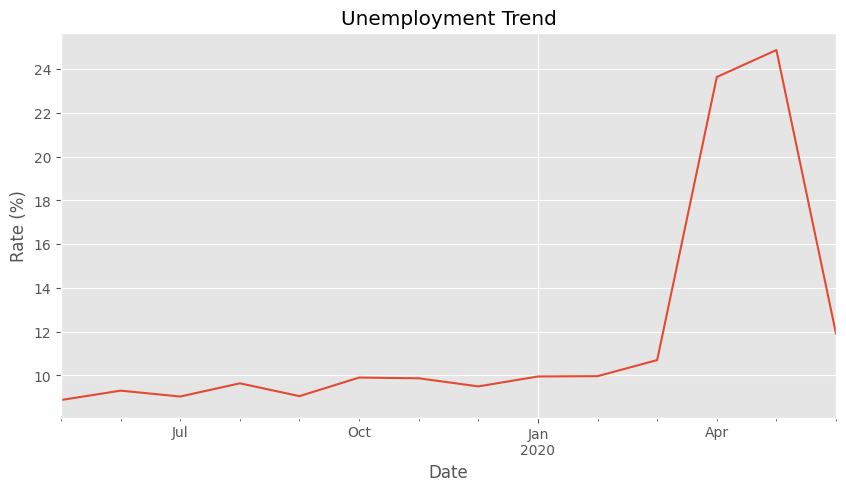

In [16]:
monthly=df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()
plt.figure(figsize=(10,5))
monthly.plot()
plt.title("Unemployment Trend")
plt.ylabel("Rate (%)")
plt.show()

### Top States by Unemployment

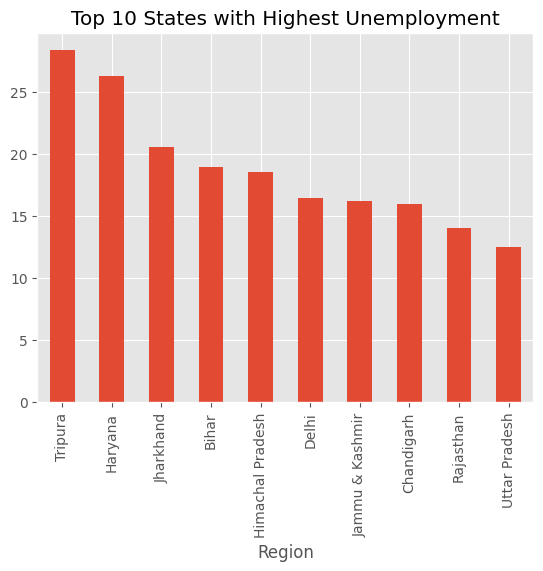

In [17]:
top_states=df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
top_states=top_states.sort_values(ascending=False)
top_states.head(10).plot(kind="bar")
plt.title("Top 10 States with Highest Unemployment")
plt.show()

### Urban Vs Rural Unemployment Analysis

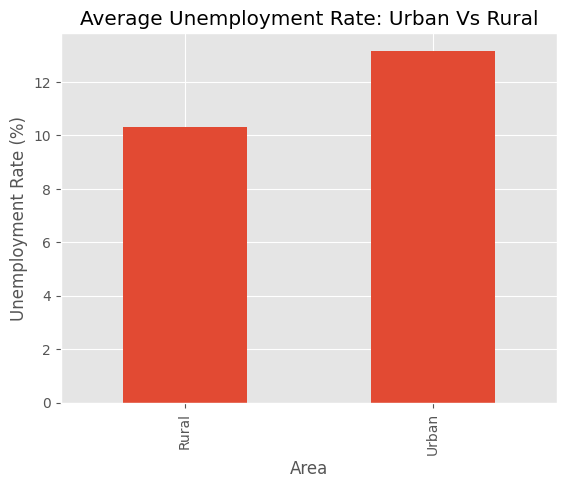

In [18]:
area_avg=df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()
area_avg.plot(kind="bar")
plt.title("Average Unemployment Rate: Urban Vs Rural")
plt.ylabel("Unemployment Rate (%)")
plt.show()

### Covid-19 Analysis

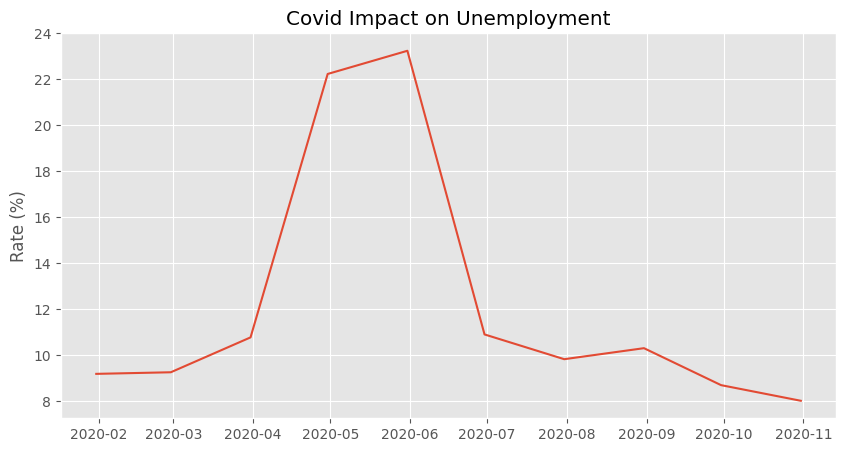

In [19]:
covid=df_covid.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(10,5))
plt.plot(covid)
plt.title("Covid Impact on Unemployment")
plt.ylabel("Rate (%)")
plt.show()

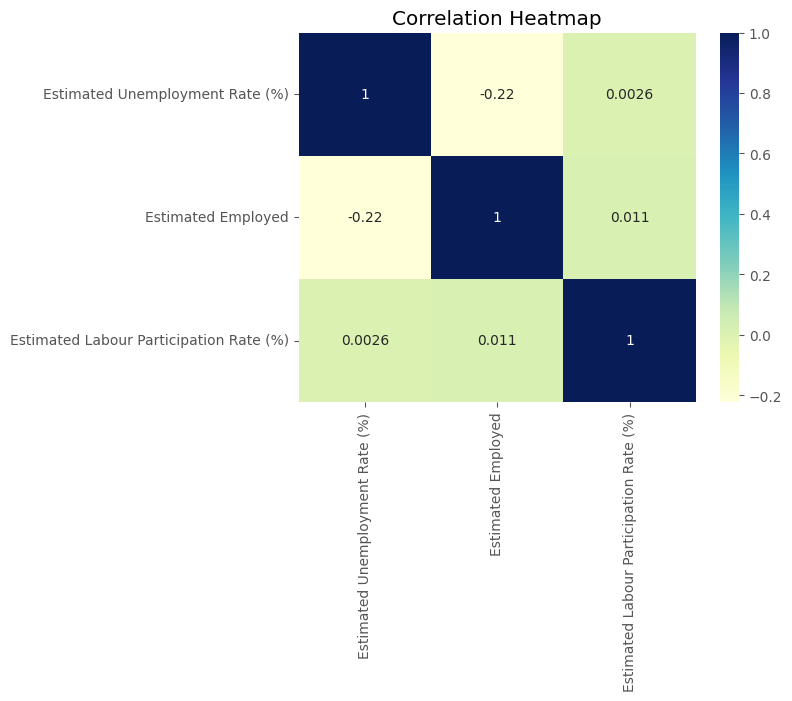

In [20]:
numeric_cols=df.select_dtypes(include="number")
sns.heatmap(numeric_cols.corr(),annot=True,cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

**Insights**

1. Unemployment rates varied across different states of India, showing regional differences in job opportunities.

2. Some states recorded higher average unemployment rates compared to others.

3. The Covid-19 pandemic had a significant impact on employment, causing unemployment rates to increase during 2020.

4. Urban and rural areas showed different unemployment patterns, indicating differences in economic activities and workforce participation.

5. Labour participation rate and employment estimates were closely related to unemployment trends.

6. Data visualization helped identify important patterns and trends in unemployment across regions and time periods.

**Conclusions**

This project analyzed unemployment data in India using Python. The dataset was cleaned, explored, and visualized to understand unemployment trends across different regions and time periods. The analysis showed that unemployment rates varied among states and increased during the Covid-19 pandemic. Overall, the project provided useful insights into employment conditions in India and demonstrated how data analysis can help in understanding economic and social issues.